# Charts & Basic Statistics

---

### Categorical data

qualitative data e.g. low, mid, high 

- *nominal*: categorical data with no natural order e.g. green, blue, red
- *ordinal (categorical)*: categorical data with natural order e.g. high school < college < uni

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess
import math

In [80]:
REPO_ROOT = Path.cwd().parents[1]
DATA_DIR = REPO_ROOT / "data"

RANDOM_SEED = 42

Data used for visualization

In [81]:
data = {
    "BMI range": [
        "Underweight",
        "Normal",
        "Overweight",
        "Obese",
    ],
    "2015 Count": [50, 400, 100, 10],
    "2015 %": ["8.9%", "71.4%", "17.9%", "1.8%"],
    "2020 Count": [45, 450, 130, 40],
    "2020 %": ["6.8%", "67.7%", "19.5%", "6.0%"],
    "2025 Count": [25, 500, 175, 50],
    "2025 %": ["3.3%", "66.7%", "23.3%", "6.7%"],
}

bmi_df = pd.DataFrame(data)
bmi_df

,BMI range,2015 Count,2015 %,2020 Count,2020 %,2025 Count,2025 %
0,Underweight,50,8.9%,45,6.8%,25,3.3%
1,Normal,400,71.4%,450,67.7%,500,66.7%
2,Overweight,100,17.9%,130,19.5%,175,23.3%
3,Obese,10,1.8%,40,6.0%,50,6.7%


### Bar chart

Used mostly for category comparison

Vertical (*plt.bar*) or horizotal (*plt.barh*)

Other bar chart types:
- *grouped bar*: comparison between groups / time periods for the same categories
- *stacked bar*: useful to visualize group composition, how it changes

Note:<br/>
Height sometimes should be *actual values* and some other times *percentage*

In [82]:
label_font = {
    "family": "Times New Roman",
    "size": 15,
}
title_font = {
    "family": "Times New Roman",
    "size": 18,
    "weight": "bold",
}
background_color = "lightgray"
edge_color = "darkgray"

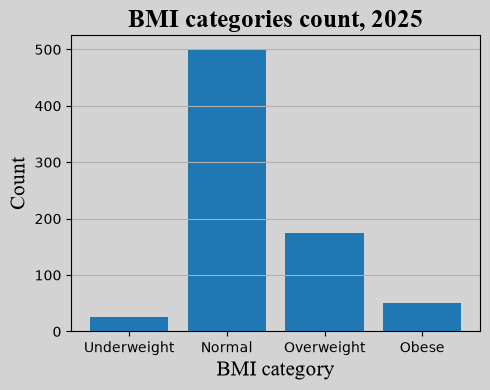

In [83]:
plt.figure(figsize=(5, 4), facecolor=background_color)
plt.gca().set_facecolor(background_color)

plt.bar(x=bmi_df["BMI range"], height=bmi_df["2025 Count"])

plt.grid(axis="y")
plt.xlabel("BMI category", fontdict=label_font)
plt.ylabel("Count", fontdict=label_font)
plt.title("BMI categories count, 2025", fontdict=title_font)
plt.tight_layout()
plt.show()

In [84]:
categories = bmi_df["BMI range"]
bmi_yearly_percentages = bmi_df.iloc[:, [2, 4, 6]].apply(
    lambda col: col.map(lambda rec: float(rec.strip("%")))
)
bmi_yearly_percentages

,2015 %,2020 %,2025 %
0,8.9,6.8,3.3
1,71.4,67.7,66.7
2,17.9,19.5,23.3
3,1.8,6.0,6.7


#### Grouped Bar Chart

- set *x* as an array of the categories
- set arrays of the data
- plot at *x +- width*

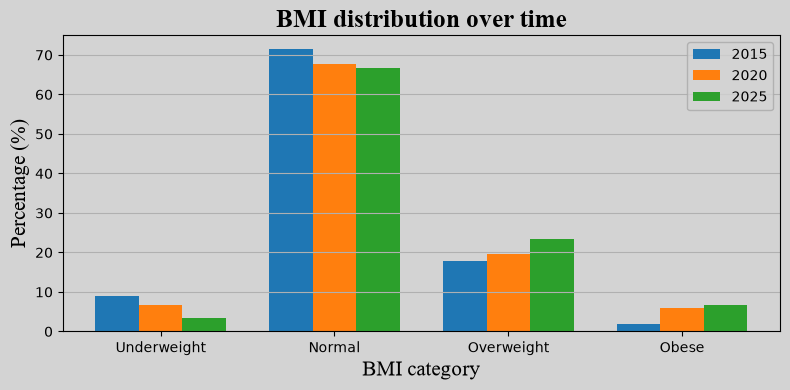

In [85]:
x = np.arange(len(categories))

plt.figure(figsize=(8, 4), facecolor=background_color)
plt.gca().set_facecolor(background_color)
width = 0.25

plt.bar(x - width, bmi_yearly_percentages["2015 %"], label="2015", width=0.25)
plt.bar(x, bmi_yearly_percentages["2020 %"], label="2020", width=0.25)
plt.bar(x + width, bmi_yearly_percentages["2025 %"], label="2025", width=0.25)

plt.xlabel("BMI category", fontdict=label_font)
plt.ylabel("Percentage (%)", fontdict=label_font)
plt.title("BMI distribution over time", fontdict=title_font)
plt.xticks(ticks=x, labels=categories)
plt.tight_layout()
plt.grid(axis="y")
plt.legend(facecolor=background_color, edgecolor=edge_color)
plt.show()

For **stacked bar chart** plot bars normally but:
- set the same *x*
- set bottom for each bar the sum(prev_heights)

### Pie chart

Shows how the whole is divided between categories 

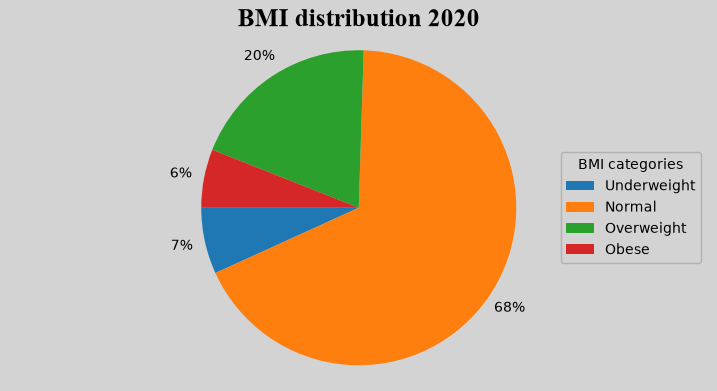

In [86]:
data_2020 = bmi_yearly_percentages["2020 %"]

plt.figure(figsize=(9, 4.5), facecolor=background_color)
wedges, texts, autotexts = plt.pie(
    x=data_2020,
    autopct="%1.0f%%",
    pctdistance=1.15,
    startangle=180,
)

plt.title("BMI distribution 2020", fontdict=title_font)
plt.legend(
    wedges,
    categories,
    title="BMI categories",
    loc="center right",
    facecolor=background_color,
    edgecolor=edge_color,
)
plt.axis("equal")
plt.show()

### Charts for Time Series Data

Most suitable: **line**, **bar** charts 

Might need aggregation like **mean** e.g. to go from monthly data to yearly 

Quick data peak

In [87]:
bases = pd.read_csv(DATA_DIR / "ece_bases.csv")
bases.head()

,Year,Base
0,2026,18.88
1,2025,18.39
2,2024,18.49
3,2023,18.82
4,2022,18.47


#### Line Chart with lowess

Provides insights in:
- trends
- increases / decreases
- peaks
- sudden changes

the lowess smoothed line is used to show the underlying trend

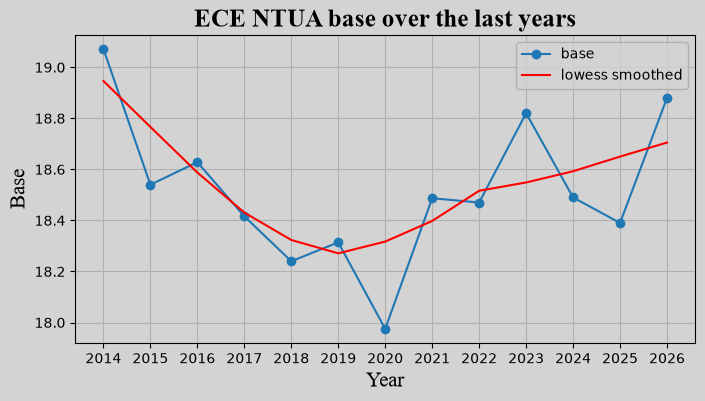

In [88]:
lowess_smoothed = lowess(bases["Base"], bases["Year"], frac=0.6)

plt.figure(figsize=(8, 4), facecolor=background_color)
plt.gca().set_facecolor(background_color)
plt.xlabel("Year", fontdict=label_font)
plt.ylabel("Base", fontdict=label_font)
plt.title("ECE NTUA base over the last years", fontdict=title_font)

plt.plot(bases["Year"], bases["Base"], marker="o", label="base")
plt.plot(
    lowess_smoothed[:, 0], lowess_smoothed[:, 1], color="red", label="lowess smoothed"
)

plt.xticks(bases["Year"])
plt.yticks()
plt.grid()
plt.legend(facecolor=background_color, edgecolor=edge_color)
plt.show()

#### Bar Chart

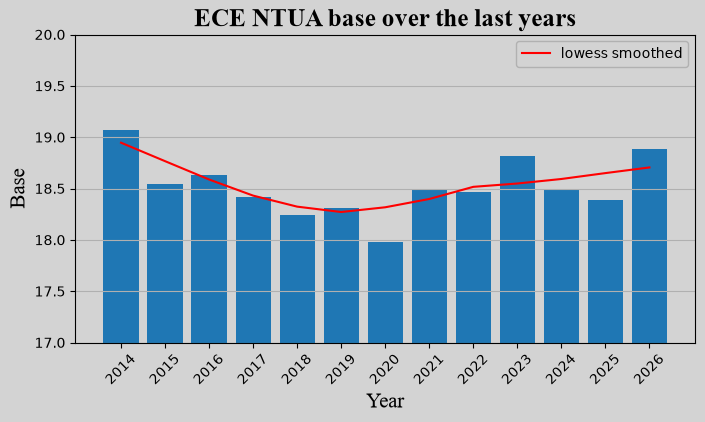

In [89]:
plt.figure(figsize=(8, 4), facecolor=background_color)
plt.gca().set_facecolor(background_color)
plt.xlabel("Year", fontdict=label_font)
plt.ylabel("Base", fontdict=label_font)
plt.title("ECE NTUA base over the last years", fontdict=title_font)

plt.plot(
    lowess_smoothed[:, 0], lowess_smoothed[:, 1], label="lowess smoothed", color="red"
)
plt.bar(bases["Year"], bases["Base"])

plt.ylim(
    math.floor(bases["Base"].min()),
    math.ceil(bases["Base"].max()),
)
plt.xticks(bases["Year"], rotation=45)
plt.yticks()
plt.grid(axis="y")
plt.legend(facecolor=background_color, edgecolor=edge_color)
plt.show()

### Descriptive statistics

- **mean** ($\mu$): very descriptive but sensitive to outliers
- **median**: more robust than mean in case of outliers
- **mode**: most frequent value
- **normal distribution**:
    - symmetrical
    - bell shaped
    - centered around mean value
    - described by *mean* and *std* ($\sigma$) values
    - $\sigma \uparrow \: \Rightarrow \text{spread} \uparrow$

![normal distribution example](https://miro.medium.com/max/1200/1*IdGgdrY_n_9_YfkaCh-dag.png)

### Histogram

Graphical display that shows the distribution and frequency of numerical data using connected bars

Shows if data is centered, skewed, or has outliers.

**Bins parameter**:
- too few => oversimplified image
- too many => noisy image

In [90]:
np.random.seed(RANDOM_SEED)
# random data that belong to a normal distribution
data = np.random.randn(100)

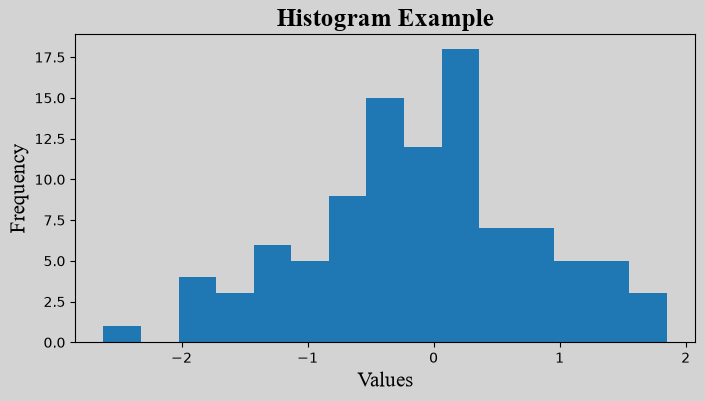

In [91]:
plt.figure(figsize=(8, 4), facecolor=background_color)
plt.gca().set_facecolor(background_color)

# note the bins parameter, experiment with this
plt.hist(data, bins=15)

plt.title("Histogram Example", fontdict=title_font)
plt.xlabel("Values", fontdict=label_font)
plt.ylabel("Frequency", fontdict=label_font)
plt.show()

### KDE - Kernel Density Estimate

Smoothed edition of the distribution

- easiest way: *sns.kdeplot(data, fill=True)*
- alternative: *scipy.stats.gaussian_kde(data)*

### Pecentiles

**Percentiles (Q)**: points to the value where left of it is the *Q%* of the data. For 4 zones (quartiles): 
- $Q1: 25\%$
- $Q2: 50\%$ (median)
- $Q3: 75\%$

**IQR**: $IQR=Q_3-Q_1$
the spread of data's middle 50%

**Outliers**: data outside the range $[Q_1-1.5IQR,\; Q_3+1.5IQR]$ 

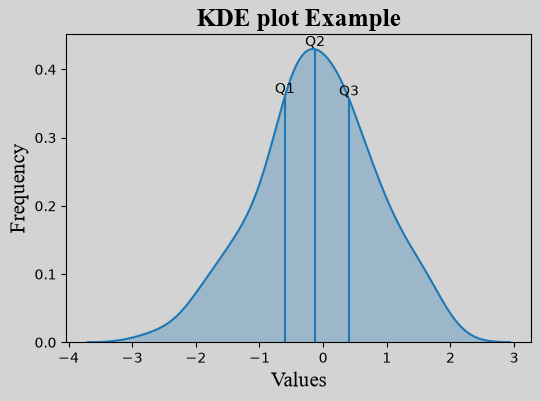

In [92]:
plt.figure(figsize=(6, 4), facecolor=background_color)
plt.gca().set_facecolor(background_color)

# KDE line
sns.kdeplot(data)

kde_line = plt.gca().lines[0]

x_kde = kde_line.get_xdata()
y_kde = kde_line.get_ydata()

plt.fill_between(x_kde, y_kde, alpha=0.3)

# Quartiles
q = np.percentile(data, [25, 50, 75])

for i in range(len(q)):
    y_q = np.interp(q[i], x_kde, y_kde)
    plt.vlines(q[i], 0, y_q)
    plt.text(
        q[i],
        y_q,
        f"Q{i + 1}",
        ha="center",
        va="bottom",
    )

plt.title("KDE plot Example", fontdict=title_font)
plt.xlabel("Values", fontdict=label_font)
plt.ylabel("Frequency", fontdict=label_font)

plt.show()

### Box Plot

![boxplot example](https://miro.medium.com/max/9000/1*2c21SkzJMf3frPXPAR_gZA.png)

summarizes:
- quartiles
- IQR
- outliers
- median
- possible sqewness

Code:
```python
sns.boxplot(data)
```

### Sqewness

The data might not be normally distributed. 
For example, most of the entries might be on the right side of the plot.
That plot is *left skewed* or *negatively skewed*. 
In that case: $mean < median < mode$

![skewness](../../assets/skewness.webp)

### Violin Plot

- *Combines* box plot, KDE 
- ideal for *comparing* different groups

Symmetrical:

![symmetrical violin plot](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT2RP3M6A79raBO199Yf6b0-vys2utA-C68Nvbghndn8QTmqQC9Ye_RSIs&s=10)

Asymmetrical: (below)

In [93]:
np.random.seed(RANDOM_SEED)
d1 = pd.DataFrame(np.random.randn(100, 1) * 10 + 8, columns=["value"])
d1["category"] = "high"
d2 = pd.DataFrame(np.random.randn(100, 1) * 10 - 6, columns=["value"])
d2["category"] = "low"
data2 = pd.concat((d1, d2))
# shuffling
data2 = data2.sample(frac=1).reset_index(drop=True)
data2.head()

,value,category
0,11.142473,high
1,-11.875689,high
2,-7.612857,low
3,-3.233092,low
4,-0.780584,low


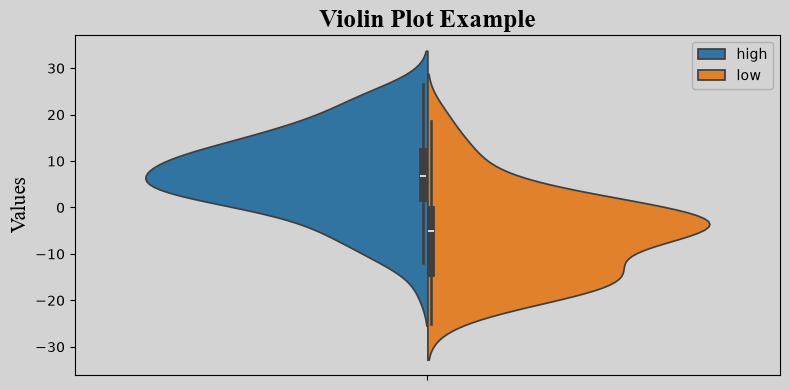

In [94]:
plt.figure(figsize=(8, 4), facecolor=background_color)
plt.gca().set_facecolor(background_color)

sns.violinplot(data=data2, split=True, y="value", hue="category")

plt.title("Violin Plot Example", fontdict=title_font)
plt.ylabel("Values", fontdict=label_font)
plt.tight_layout()
plt.legend(facecolor=background_color, edgecolor=edge_color)
plt.show()

### Association

Using `plt.scatter(x, y)` we can create plots like below and observe association in type and strength:

Types

![association types](../../assets/association%20type.webp)

Strength

![association strength](../../assets/association%20strength.webp)

### Pearson Correlation $r$

$-1\le r\le1$

Interpretation:
- $r\approx1$: strong positive relationship
- $r\approx-1$: strong negative relationship
- $r\approx0$: no **linear** relationship (there might exist some other kind of relationship)

Code:

```python
from scipy.stats import pearsonr

r, p = pearsonr(x, y)
```

### Simpson's Paradox

a statistical phenomenon where a trend or relationship that appears in different groups of data disappears or reverses entirely when those groups are combined

![Simpson's paradox example](https://cdn.ncbi.nlm.nih.gov/pmc/blobs/249d/3740239/133369d4326e/fpsyg-04-00513-g0001.jpg)

So *always* inspect subgroups

## Summary

### Logical pipeline 

*Raw data* -> *Descriptive statistics* -> *Distribution* -> *Visualization* -> *Relationships* -> *Interpretation*

### Key Questions 

For **single categorical** variable:

- How categories are distributed: *bar* / *pie*
- Timely changes: *line plot*

For **single numerical** variable:

- What is the distribution like: *histogram* / *KDE* / *box plot* / *violin plot*

For **2 numerical** variables:

- How are the correlated: *scatter plot* / *reg plot*

For **multiple groups**:

- How distributions differ: *box plot* / *violin plot* / *grouped plots*